In [ ]:
from pathlib import Path
import importlib.util

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CAUSALISED_GC_PATH = (
    PROJECT_ROOT
    / "src"
    / "markovianity_diagnostic"
    / "core"
    / "causalised-GC.py"
)
spec = importlib.util.spec_from_file_location("causalised_gc", CAUSALISED_GC_PATH)
causalised_gc = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(causalised_gc)
GcStar = causalised_gc.GcStar

from markovianity_diagnostic.core.utils import adj_mtx, continuous_noise_fun

from tqdm.notebook import tqdm

## Simulate data

An example ground truth connectivity matrix `A`

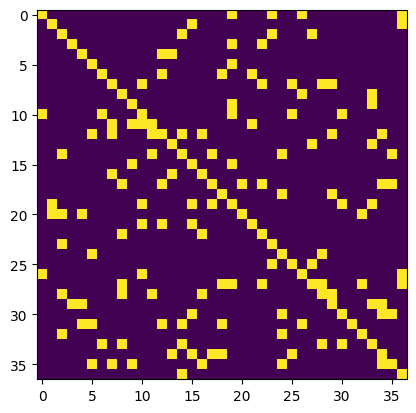

In [2]:
plt.imshow(adj_mtx(np.random.randint(25,40,1)[0])!=0)

## Analysis

In [3]:
metrics, N_PASTS, num = [], list(range(1, 8)), 10
for a in tqdm(range(num)):
    n_neur = np.random.randint(18, 30, 1)[0]
    l = np.random.randint(5000, 10000, 1)[0]
    alpha, beta, n_lags = 0.01, 0.001, 1

    # simulate data

    A = adj_mtx(n_neur)
    X = np.zeros((A.shape[0], l)).T
    X[0] = np.random.randn(A.shape[0])
    for i, row in enumerate(X[:-1]):
        X[i+1] = A @ X[i] + np.random.normal(0,0.25,A.shape[0])
    X=X.T

    print(f'Data {a} of {num} with {X.shape[0]} vars')

    # fit algorithm to data
    met = np.zeros((len(N_PASTS), 6))
    for k, n_past in enumerate(N_PASTS):
        print(n_past)

        # intantiate the GcStar()
        gcstar = GcStar(n_perm = 1000, n_pasts = n_past, n_lags = n_lags, temporal = True, method="cgc")
        gcstar.fit(X, verbose=0)

        # compute metrics
        gcstar.get_connectivity_matrix(alpha=alpha, beta=beta,simulation=True)
        gcstar.compute_confusion_matrix(A, simulation=True)
        met[k] = np.round(gcstar.compute_metrics(), decimals=4)
    metrics.append(met)

  0%|          | 0/10 [00:00<?, ?it/s]

Data 0 of 10 with 18 vars
1
2
3
4
5
6
7
Data 1 of 10 with 28 vars
1
2
3
4
5
6
7
Data 2 of 10 with 25 vars
1
2
3
4
5
6
7
Data 3 of 10 with 22 vars
1
2
3
4
5
6
7
Data 4 of 10 with 28 vars
1
2
3
4
5
6
7
Data 5 of 10 with 21 vars
1
2
3
4
5
6
7
Data 6 of 10 with 27 vars
1
2
3
4
5
6
7
Data 7 of 10 with 20 vars
1
2
3
4
5
6
7
Data 8 of 10 with 20 vars
1
2
3
4
5
6
7
Data 9 of 10 with 29 vars
1
2
3
4
5
6
7


In [4]:
for met in metrics:
    print(met)

[[0.9938 1.     0.9459 0.     0.973  0.9722]
 [0.9938 1.     0.9459 0.     0.973  0.9722]
 [0.9938 1.     0.9459 0.     0.973  0.9722]
 [0.9907 1.     0.9189 0.     0.9595 0.9577]
 [0.9938 1.     0.9459 0.     0.973  0.9722]
 [0.9938 1.     0.9459 0.     0.973  0.9722]
 [0.9938 1.     0.9459 0.     0.973  0.9722]]
[[0.9847 0.9775 0.8969 0.0029 0.947  0.9355]
 [0.986  0.9778 0.9072 0.0029 0.9522 0.9412]
 [0.986  0.9778 0.9072 0.0029 0.9522 0.9412]
 [0.9872 0.9888 0.9072 0.0015 0.9529 0.9462]
 [0.986  0.9778 0.9072 0.0029 0.9522 0.9412]
 [0.9847 0.967  0.9072 0.0044 0.9514 0.9362]
 [0.986  0.9778 0.9072 0.0029 0.9522 0.9412]]
[[1.     1.     1.     0.     1.     1.    ]
 [0.9984 0.9855 1.     0.0018 0.9991 0.9927]
 [0.9984 0.9855 1.     0.0018 0.9991 0.9927]
 [0.9968 0.9714 1.     0.0036 0.9982 0.9855]
 [0.9936 0.9571 0.9853 0.0054 0.99   0.971 ]
 [0.9968 0.9714 1.     0.0036 0.9982 0.9855]
 [0.9984 0.9855 1.     0.0018 0.9991 0.9927]]
[[0.9897 0.9815 0.9298 0.0023 0.9637 0.955 ]
 [0.991

In [5]:
Metrics = np.zeros((num,7,6))
for i, met in enumerate(metrics):
    Metrics[i] = met
np.mean(Metrics[:,0,0])

np.float64(0.9929499999999999)

In [6]:
np.mean(Metrics,axis=0)

array([[9.9295e-01, 9.8493e-01, 9.5209e-01, 1.9000e-03, 9.7509e-01,
        9.6779e-01],
       [9.9287e-01, 9.8756e-01, 9.5040e-01, 1.7400e-03, 9.7434e-01,
        9.6816e-01],
       [9.9312e-01, 9.8926e-01, 9.5034e-01, 1.4700e-03, 9.7444e-01,
        9.6895e-01],
       [9.9287e-01, 9.8684e-01, 9.4954e-01, 1.6300e-03, 9.7397e-01,
        9.6735e-01],
       [9.9341e-01, 9.8970e-01, 9.5165e-01, 1.3600e-03, 9.7515e-01,
        9.6983e-01],
       [9.9368e-01, 9.9262e-01, 9.5090e-01, 9.4000e-04, 9.7497e-01,
        9.7081e-01],
       [9.9324e-01, 9.8621e-01, 9.5312e-01, 1.7100e-03, 9.7571e-01,
        9.6892e-01]])

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/var/folders/my/b625dwwn62x214n4rwpf336c0000gn/T/ipykernel_41019/3409937405.py:3: SyntaxWarning: invalid escape sequence '\m'
  lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$', '$\mu_{BA}$', '$\mu_{F1}$']
/var/folders/my/b625dwwn62x214n4rwpf336c0000gn/T/ipykernel_41019/3409937405.py:3: SyntaxWarning: invalid escape sequence '\m'
  lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$

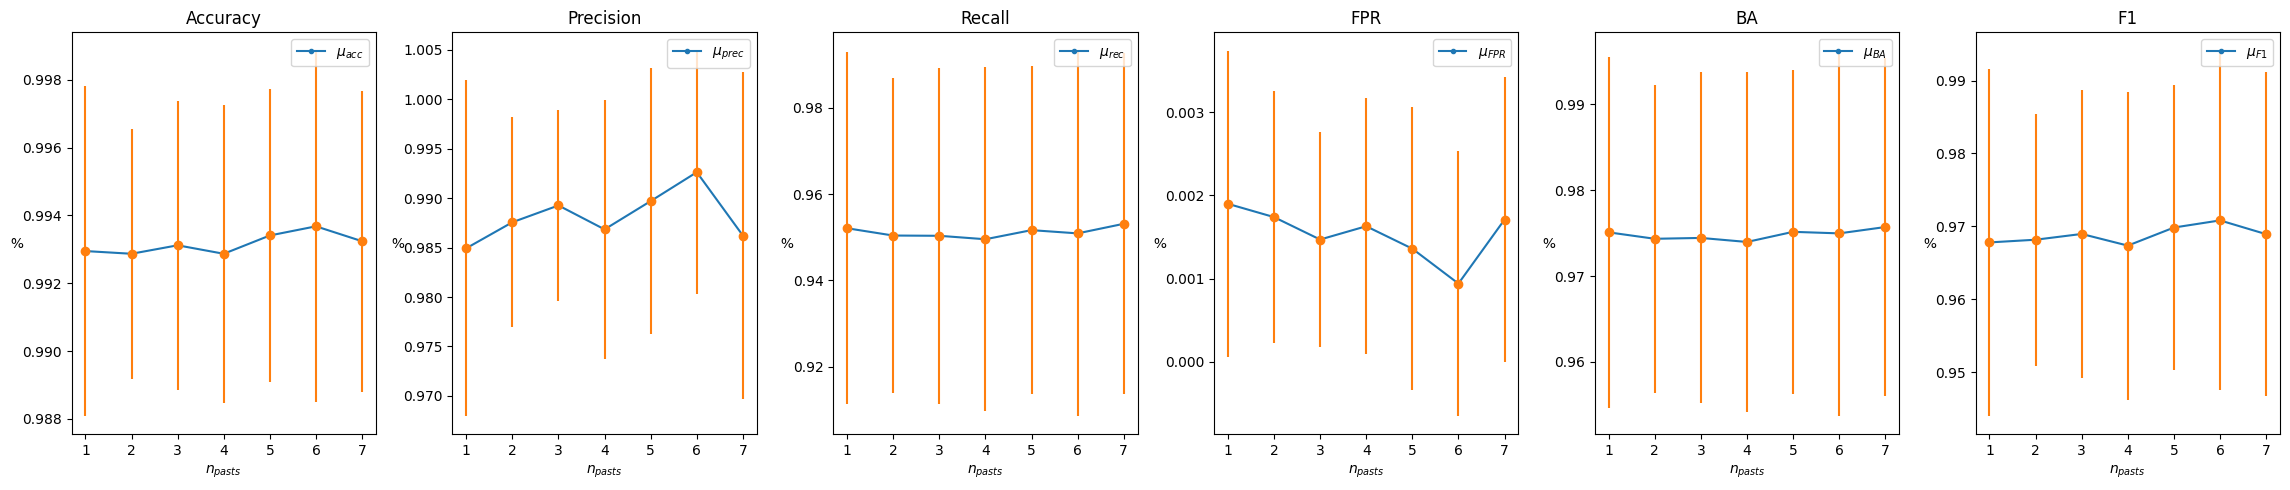

In [7]:
fig, ax = plt.subplots(1, 6, figsize = (23, 5))
labels = ['Accuracy', 'Precision', 'Recall', 'FPR', 'BA', 'F1']
lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$', '$\mu_{BA}$', '$\mu_{F1}$']
for i in range(Metrics.shape[2]):
    ax[i].plot(range(1, 1 + Metrics.shape[1]),
               np.mean(Metrics, axis = 0)[:, i],
               marker = '.', label = lab[i])

    ax[i].errorbar(range(1, 1 + Metrics.shape[1]),
                   np.mean(Metrics, axis = 0)[:, i],
                   yerr = np.std(Metrics, axis = 0)[:, i],
                   fmt='o')
    ax[i].set_xticks(range(1,1+Metrics.shape[1]),
                     list(range(1, 1+Metrics.shape[1])))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
    ax[i].legend()
    plt.tight_layout()